In [ ]:
import torch
from torch_geometric.data import HeteroData

PROCESSED_DIR = '../data/processed/'

In [ ]:
# 1. Load Pre-computed Artifacts

print("Loading node features...")
x_user = torch.load(PROCESSED_DIR + 'x_dict_user.pt', weights_only=True)
x_item = torch.load(PROCESSED_DIR + 'x_dict_item.pt', weights_only=True)

print("Loading edge indices...")
user_item_edge_index = torch.load(PROCESSED_DIR + 'user_item_edge_index.pt', weights_only=True)
item_item_edge_index = torch.load(PROCESSED_DIR + 'item_item_edge_index.pt', weights_only=True)

print(f"  x_user shape          : {x_user.shape}")
print(f"  x_item shape          : {x_item.shape}")
print(f"  user->item edge_index : {user_item_edge_index.shape}")
print(f"  item->item edge_index : {item_item_edge_index.shape}")

In [ ]:
# 2. Construct `HeteroData` Object

data = HeteroData()

# --- Node features ---
data['user'].x = x_user   
data['item'].x = x_item   

# --- Edge indices ---
# user --reviews--> item
data['user', 'reviews', 'item'].edge_index = user_item_edge_index   

# item --also_bought--> item
data['item', 'also_bought', 'item'].edge_index = item_item_edge_index  

print(data)

In [ ]:
# 3. Validate the Graph

print("=== HeteroData Summary ===")
print(f"Node types  : {data.node_types}")
print(f"Edge types  : {data.edge_types}")
print()
print(f"data['user'].x          : {data['user'].x.shape}")
print(f"data['item'].x          : {data['item'].x.shape}")
print()
print(f"data['user','reviews','item'].edge_index    : {data['user', 'reviews', 'item'].edge_index.shape}")
print(f"data['item','also_bought','item'].edge_index: {data['item', 'also_bought', 'item'].edge_index.shape}")
print()

# Sanity checks
num_users = data['user'].x.shape[0]
num_items = data['item'].x.shape[0]

ui_idx = data['user', 'reviews', 'item'].edge_index
ii_idx = data['item', 'also_bought', 'item'].edge_index

assert ui_idx.shape[0] == 2, "user->item edge_index must have shape [2, E]"
assert ii_idx.shape[0] == 2, "item->item edge_index must have shape [2, E]"
assert ui_idx[0].max() < num_users, "user node index out of range"
assert ui_idx[1].max() < num_items, "item node index out of range (user->item)"
assert ii_idx[0].max() < num_items, "item src index out of range (item->item)"
assert ii_idx[1].max() < num_items, "item dst index out of range (item->item)"

print("All sanity checks passed!")

In [ ]:
# 4. Save the HeteroData Object

save_path = PROCESSED_DIR + 'hetero_data.pt'
torch.save(data, save_path)
print(f"HeteroData object saved to {save_path}")

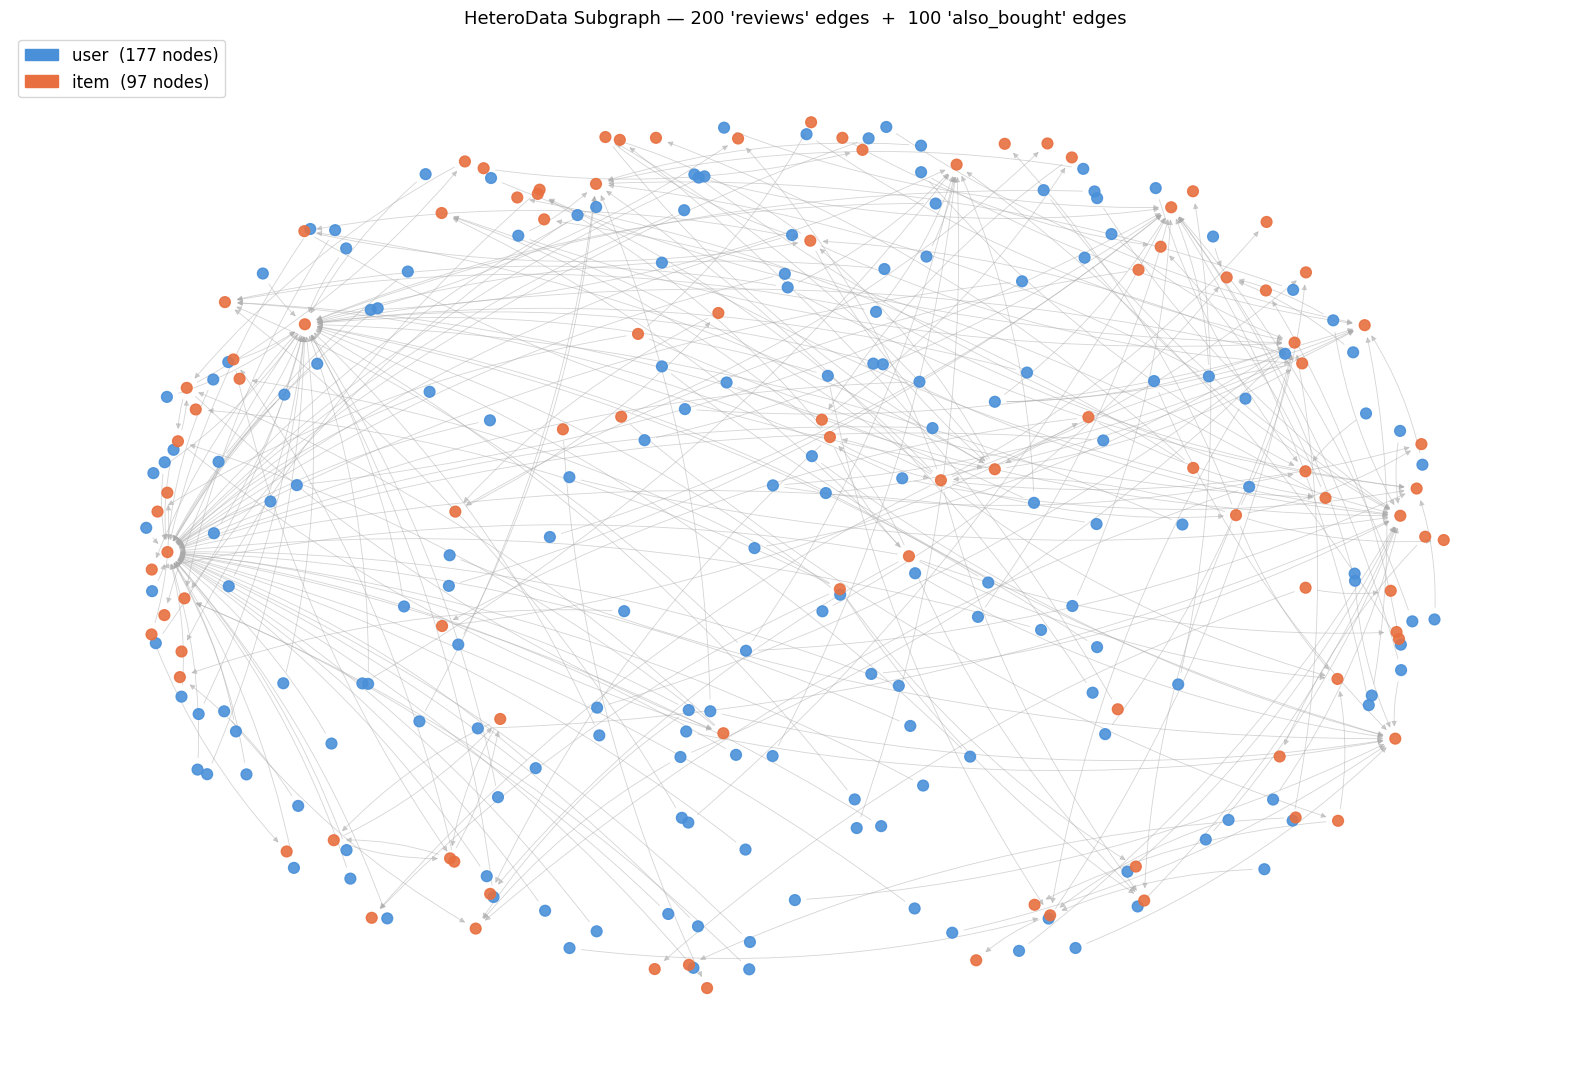

In [8]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ── Configuration ────────────────────────────────────────────────────
K_REVIEWS     = 200   # number of user->item edges to sample
K_ALSO_BOUGHT = 100   # number of item->item edges to sample

# ── Build a sampled NetworkX graph ───────────────────────────────────
G = nx.DiGraph()

ui_idx = data['user', 'reviews', 'item'].edge_index
ii_idx = data['item', 'also_bought', 'item'].edge_index

for i in range(min(K_REVIEWS, ui_idx.shape[1])):
    u = f"u{ui_idx[0, i].item()}"
    v = f"i{ui_idx[1, i].item()}"
    G.add_node(u, ntype='user')
    G.add_node(v, ntype='item')
    G.add_edge(u, v, rel='reviews')

for i in range(min(K_ALSO_BOUGHT, ii_idx.shape[1])):
    src = f"i{ii_idx[0, i].item()}"
    dst = f"i{ii_idx[1, i].item()}"
    G.add_node(src, ntype='item')
    G.add_node(dst, ntype='item')
    G.add_edge(src, dst, rel='also_bought')

# ── Draw ─────────────────────────────────────────────────────────────
color_map = {
    'user': '#4A90D9',   # blue
    'item': '#E87040',   # orange
}
node_colors = [color_map[G.nodes[n]['ntype']] for n in G.nodes]

pos = nx.spring_layout(G, seed=42, k=0.6)

plt.figure(figsize=(16, 11))
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=60, alpha=0.9)
nx.draw_networkx_edges(
    G, pos,
    edge_color='#aaaaaa', alpha=0.5, arrows=True,
    arrowsize=8, width=0.6,
    connectionstyle='arc3,rad=0.1'
)
plt.legend(
    handles=[
        Patch(color=color_map['user'], label=f"user  ({sum(1 for n in G.nodes if G.nodes[n]['ntype']=='user')} nodes)"),
        Patch(color=color_map['item'], label=f"item  ({sum(1 for n in G.nodes if G.nodes[n]['ntype']=='item')} nodes)"),
    ],
    loc='upper left', fontsize=12
)
plt.title(
    f"HeteroData Subgraph — {K_REVIEWS} 'reviews' edges  +  {K_ALSO_BOUGHT} 'also_bought' edges",
    fontsize=13
)
plt.axis('off')
plt.tight_layout()
plt.show()
